# Fine-tuning d'un petit LLM avec QLoRA pour le Text-to-SQL financier

**Parameter-Efficient Fine-Tuning (LoRA) for a Domain-Specific Task**

| | |
|---|---|
| **Modèle** | Qwen2.5-Coder-1.5B-Instruct (open source, Apache 2.0) |
| **Méthode** | QLoRA : modèle de base en 4 bits + adaptateurs LoRA (r = 16) |
| **Données** | Gretel `synthetic_text_to_sql`, domaines financiers |
| **Matériel** | 1 GPU NVIDIA T4 (Google Colab gratuit) |
| **Résultat** | Execution accuracy : **58,9 % → 71,5 %** (+12,7 points, p = 0,0002) |


**Plan**
1. Problématique
2. État de l'art
3. Dataset
4. Nettoyage et préparation
5. Baseline
6. Entraînement avec LoRA
7. Résultats
8. Benchmarking
9. Limitations
10. Conclusion
11. Références



## 0. Installation et configuration

In [1]:
import os, sys

REPO_URL = "https://github.com/eya-bouhmida/finance-text2sql-lora.git"
REPO_DIR = "/content/finance-text2sql-lora"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    else:
        !cd {REPO_DIR} && git pull
    %cd {REPO_DIR}
    !pip install -q transformers accelerate peft trl bitsandbytes datasets
    !pip uninstall -y -q torchao   # conflit avec peft dans Colab, inutile pour ce projet
    sys.path.append(REPO_DIR)
    from google.colab import drive
    drive.mount("/content/drive")
else:
    sys.path.append(".")

DRIVE_DIR = "/content/drive/MyDrive/text2sql-finance-qlora" if IN_COLAB else "."
DATA_DIR = f"{DRIVE_DIR}/data"
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints/qlora-r16"
ADAPTER_DIR = f"{DRIVE_DIR}/adapters/qlora-r16"
RESULTS_DIR = f"{DRIVE_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# False : on réutilise l'adaptateur déjà entraîné (sur Drive).
# True  : on relance l'entraînement complet (≈ 20 minutes sur T4).
RELANCER_ENTRAINEMENT = False

Cloning into '/content/finance-text2sql-lora'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 84 (delta 46), reused 48 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 279.16 KiB | 8.21 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/finance-text2sql-lora
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.8/945.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.0 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Mounted at /content/drive


In [2]:
import gc, json, time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import data as D, model as M, evaluate as E, train as T

pd.set_option("display.max_colwidth", 150)
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "AUCUN (active le GPU T4)")

GPU : Tesla T4


## 1. Problématique

Les équipes métier d'une institution financière (analystes, contrôleurs, managers) ont besoin d'interroger des bases SQL mais ne savent pas écrire de SQL : elles dépendent de l'équipe data, ce qui crée des délais. Les grands LLM propriétaires savent traduire une question en SQL, mais une banque ne peut pas toujours leur envoyer ses schémas et ses questions, pour des raisons de confidentialité, de conformité et de coût.

> **Question du projet :** un petit modèle open source, fine-tuné avec LoRA sur un seul GPU, peut-il générer des requêtes SQL fiables sur des bases financières, tout en restant déployable en interne ?

**Fonctionnement :** le modèle reçoit le **schéma** de la base (`CREATE TABLE`) et une question, et génère une requête SQL. Il ne voit **jamais les données** : c'est notre code qui exécute la requête.

## 2. État de l'art

Plusieurs travaux ont étudié la génération de requêtes SQL dans la finance. **BIRD** (2023) montre que les LLM peinent sur des bases réelles, où seuls les très gros modèles atteignent environ 80 %. **BookSQL** (2024) confirme que même GPT-4 échoue souvent en comptabilité. **FinSQL** (2024) montre que LoRA permet d'adapter un LLM à la finance à faible coût.

Ce projet se place dans un cadre plus contraint : un modèle de 1,5 milliard de paramètres et un seul GPU gratuit.

## 3. Dataset

**Gretel `synthetic_text_to_sql`** (licence Apache 2.0) : environ 105 000 exemples synthétiques couvrant 100 domaines. Chaque exemple contient une question, le contexte SQL (`CREATE TABLE` + `INSERT`) et la requête de référence. Comme le contexte contient des données, on peut **créer une mini-base SQLite et exécuter les requêtes**.

In [3]:
train_raw, test_raw = D.load_gretel()
print(f"Train : {len(train_raw):,} exemples | Test : {len(test_raw):,} exemples | Domaines : {train_raw['domain'].nunique()}")

ex = train_raw.iloc[0]
for col in ["domain", "sql_complexity", "sql_prompt", "sql_context", "sql"]:
    print(f"--- {col} ---\n{ex[col]}\n")

README.md:   0%|          | 0.00/8.19k [00:00<?, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…): reconstructing file:   0%|          |  0.00B / 32.4MB            

synthetic_text_to_sql_train.snappy.parqu(…): downloading bytes:           |  0.00B            

synthetic_text_to_sql_test.snappy.parque(…): reconstructing file:   0%|          |  0.00B / 1.90MB            

synthetic_text_to_sql_test.snappy.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5851 [00:00<?, ? examples/s]

Train : 100,000 exemples | Test : 5,851 exemples | Domaines : 100
--- domain ---
forestry

--- sql_complexity ---
single join

--- sql_prompt ---
What is the total volume of timber sold by each salesperson, sorted by salesperson?

--- sql_context ---
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');

--- sql ---
SELECT salesperson_id, name, SUM(volume) as total_volume FROM timber_sales JOIN salesperson ON timber_sales.salesperson_id = salesperson.salesperson_id GROUP BY salesperson_id, name ORDER BY total_volume DESC;



In [4]:
FINANCE_DOMAINS = D.find_finance_domains(train_raw["domain"].unique())
train_fin = D.filter_domains(train_raw, FINANCE_DOMAINS)
test_fin = D.filter_domains(test_raw, FINANCE_DOMAINS)

print("Domaines financiers retenus :", FINANCE_DOMAINS)
print(f"Train finance : {len(train_fin):,} | Test finance : {len(test_fin):,}")

Domaines financiers retenus : ['finance', 'financial services', 'insurance', 'social impact investing', 'venture capital']
Train finance : 4,565 | Test finance : 258


## 4. Nettoyage et préparation

| Étape | Pourquoi |
|---|---|
| Tâches en lecture seule, requêtes `SELECT` uniquement | Le cas d'usage est un analyste qui **interroge** une base, sans jamais la modifier |
| Suppression des doublons | Éviter la mémorisation et les fuites entre train et test |
| Vérification de l'exécution dans SQLite | Écarter les requêtes en syntaxe MySQL / PostgreSQL, qu'on ne pourrait pas évaluer |
| Test : suppression des résultats vides | Sinon, toute requête qui ne renvoie rien serait comptée juste |
| Retrait du train des questions présentes dans le test | Le test doit rester inconnu du modèle |

In [5]:
train_clean, train_report, _ = D.clean_dataset(train_fin)
test_clean, test_report, _ = D.clean_dataset(test_fin, require_non_empty=True)
pd.DataFrame({"Train": train_report, "Test": test_report})

,Train,Test
départ,4565.0,258
après filtre lecture seule,4130.0,235
après filtre SELECT,4130.0,235
après suppression doublons,4130.0,235
après suppression vides,4130.0,235
après vérification exécution SQLite,3118.0,177
après suppression résultats vides,NaN,158


Les fichiers `train.jsonl`, `val.jsonl` et `test.jsonl` produits par cette préparation (séparation 90/10 du train, graine 42) sont stockés sur Drive et réutilisés ci-dessous. Chaque exemple est mis au format conversation : **système** (consigne), **utilisateur** (schéma + question), **assistant** (requête SQL attendue).

In [6]:
train_records = D.load_jsonl(f"{DATA_DIR}/train.jsonl")
val_records = D.load_jsonl(f"{DATA_DIR}/val.jsonl")
test_records = D.load_jsonl(f"{DATA_DIR}/test.jsonl")
print(f"Train : {len(train_records)} | Validation : {len(val_records)} | Test : {len(test_records)}")

print()
for m in train_records[0]["messages"]:
    print(f"[{m['role'].upper()}]\n{m['content']}\n")

Train : 2806 | Validation : 312 | Test : 158

[SYSTEM]
You are an expert SQL assistant for financial databases. Given a database schema and a question, write a single SQLite query that answers it. Return only the SQL query.

[USER]
### Schema:
CREATE TABLE social_impact_investments (id INT, country VARCHAR(50), transaction_value FLOAT);

### Question:
What is the maximum transaction value for social impact investments in the United Kingdom?

[ASSISTANT]
SELECT MAX(transaction_value) FROM social_impact_investments WHERE country = 'United Kingdom';



## 5. Baseline

Le modèle de base **Qwen2.5-Coder-1.5B-Instruct** est évalué **sans aucun entraînement** sur les questions de test.

| Métrique | Signification |
|---|---|
| **Execution accuracy** (principale) | La requête générée renvoie le même résultat que la requête de référence (convention BIRD) |
| SQL valide | La requête s'exécute sans erreur |
| Exact match | Le texte SQL est identique à la référence (indicatif) |

Le décodage est **glouton** (déterministe) : les résultats sont reproductibles.

In [7]:
messages = [r["messages"] for r in test_records]

def run_model(adapter_path=None):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    model, tokenizer = M.load_model(M.BASE_MODEL, adapter_path=adapter_path)
    outputs, sec = M.generate(model, tokenizer, messages, batch_size=8)
    peak_gb = torch.cuda.max_memory_allocated() / 1e9
    del model
    gc.collect(); torch.cuda.empty_cache()
    return outputs, sec, peak_gb

base_out, base_sec, base_mem = run_model(adapter_path=None)
base_res = E.evaluate_predictions(test_records, base_out)
base_sum = E.summarize(base_res)
pd.Series(base_sum)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

158/158


,0
n,158.00
execution_accuracy,58.86
valid_sql_rate,92.41
exact_match,24.68


In [8]:
E.summarize_by(base_res, "sql_complexity")

,n,execution_accuracy,valid_sql_rate
sql_complexity,,,
basic SQL,79,67.1,97.5
single join,35,54.3,82.9
aggregation,31,54.8,100.0
window functions,6,33.3,83.3
subqueries,5,40.0,60.0
multiple_joins,2,0.0,50.0


**Lecture :** le modèle de base maîtrise déjà la syntaxe SQL (plus de 90 % de requêtes valides), mais environ un tiers de ses réponses sont des requêtes valides qui renvoient un mauvais résultat. Son point faible est la compréhension de la question et du schéma, plus que la syntaxe.

## 6. Entraînement avec LoRA (QLoRA)

**LoRA** gèle les poids **W** du modèle et apprend, à côté de chaque couche linéaire, une petite correction **ΔW = B·A** de rang r = 16. **QLoRA** charge en plus le modèle gelé en **4 bits**, ce qui divise sa mémoire par 4. Seules les matrices A et B sont entraînées.

| Hyperparamètre | Valeur | Justification |
|---|---|---|
| `r` / `lora_alpha` | 16 / 32 | Bon compromis capacité / taille ; alpha = 2 × r |
| `target_modules` | toutes les couches linéaires | Recommandation de l'article QLoRA |
| `learning_rate` | 2e-4 | Valeur standard pour LoRA |
| Epochs | 2 | Surveillance du surapprentissage par la validation |
| Batch effectif | 16 | 4 exemples × 4 pas d'accumulation |
| Loss | sur la requête SQL uniquement | Le modèle apprend à produire le SQL, pas à recopier le schéma |

In [9]:
if RELANCER_ENTRAINEMENT:
    train_ds = T.to_prompt_completion(train_records)
    val_ds = T.to_prompt_completion(val_records)
    model, tokenizer = T.load_quantized_model(T.BASE_MODEL)
    trainer = T.build_trainer(model, tokenizer, train_ds, val_ds,
                              T.make_lora_config(), T.make_training_args(CHECKPOINT_DIR))
    start = time.time()
    trainer.train(resume_from_checkpoint=T.latest_checkpoint(CHECKPOINT_DIR))
    train_minutes = round((time.time() - start) / 60, 1)
    trainer.model.save_pretrained(ADAPTER_DIR)
    tokenizer.save_pretrained(ADAPTER_DIR)
    log_history = trainer.state.log_history
    del model, trainer
    gc.collect(); torch.cuda.empty_cache()
else:
    # Réutilisation de l'entraînement déjà effectué : l'historique est relu depuis le dernier checkpoint
    with open(f"{T.latest_checkpoint(CHECKPOINT_DIR)}/trainer_state.json") as f:
        log_history = json.load(f)["log_history"]
    train_minutes = 18.5   # mesuré lors de l'entraînement (notebook 03)
    print("Entraînement non relancé : adaptateur chargé depuis", ADAPTER_DIR)

Entraînement non relancé : adaptateur chargé depuis /content/drive/MyDrive/text2sql-finance-qlora/adapters/qlora-r16


In [10]:
import struct

# Nombre exact de paramètres entraînés, lu dans l'en-tête du fichier de l'adaptateur
with open(f"{ADAPTER_DIR}/adapter_model.safetensors", "rb") as f:
    header = json.loads(f.read(struct.unpack("<Q", f.read(8))[0]))
trainable = sum(int(np.prod(v["shape"])) for k, v in header.items() if k != "__metadata__")
TOTAL_BASE_PARAMS = 1.54e9
adapter_mb = T.dir_size_mb(ADAPTER_DIR)

pd.Series({
    "Paramètres entraînés": f"{trainable:,}",
    "Part du modèle": f"{100 * trainable / TOTAL_BASE_PARAMS:.2f} %",
    "Durée d'entraînement": f"{train_minutes} min (GPU T4)",
    "Taille de l'adaptateur": f"{adapter_mb} Mo (contre ≈ 3 000 Mo pour le modèle complet)",
})

,0
Paramètres entraînés,"18,464,768"
Part du modèle,1.20 %
Durée d'entraînement,18.5 min (GPU T4)
Taille de l'adaptateur,85.3 Mo (contre ≈ 3 000 Mo pour le modèle complet)


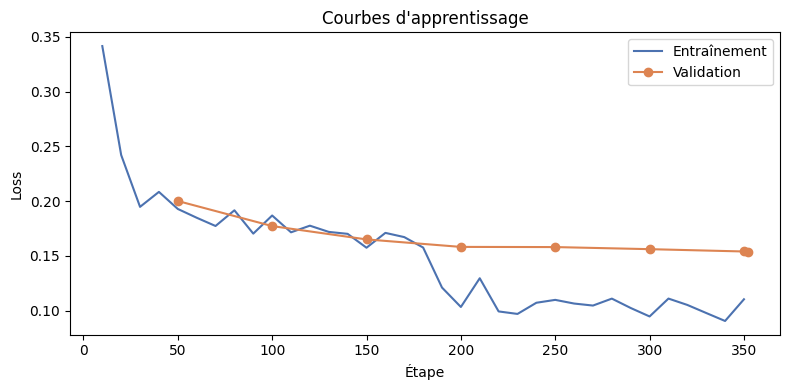

In [11]:
logs = pd.DataFrame(log_history)
train_loss = logs.dropna(subset=["loss"])[["step", "loss"]]
eval_loss = logs.dropna(subset=["eval_loss"])[["step", "eval_loss"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_loss["step"], train_loss["loss"], label="Entraînement", color="#4C72B0")
ax.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation", color="#DD8452", marker="o")
ax.set_xlabel("Étape"); ax.set_ylabel("Loss"); ax.set_title("Courbes d'apprentissage")
ax.legend(); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/learning_curves.png", dpi=150)
plt.show()

**Lecture :** pas de sous-apprentissage. Pendant la première epoch, les deux losses baissent ensemble. Au début de la deuxième epoch (≈ étape 180), la loss d'entraînement chute alors que la validation se stabilise : le modèle commence à mémoriser les exemples déjà vus. La validation ne remonte pas, il n'y a donc pas de surapprentissage nuisible, mais une epoch supplémentaire n'apporterait probablement rien. Le checkpoint avec la meilleure loss de validation est conservé.

## 7. Résultats

Le modèle fine-tuné (modèle de base + adaptateur LoRA) est évalué sur **les mêmes questions**, avec **le même chargement** (float16) et **le même décodage** que la baseline.

In [12]:
ft_out, ft_sec, ft_mem = run_model(adapter_path=ADAPTER_DIR)
ft_res = E.evaluate_predictions(test_records, ft_out)
ft_sum = E.summarize(ft_res)

n = len(test_records)
def row(name, s, res, sec, mem, trained, size):
    lo, hi = E.wilson_ci(int(res["execution_match"].sum()), n)
    return {"Modèle": name,
            "Execution accuracy (%)": s["execution_accuracy"],
            "IC 95 % (%)": f"[{lo} ; {hi}]",
            "SQL valide (%)": s["valid_sql_rate"],
            "Exact match (%)": s["exact_match"],
            "Temps / question (s)": round(sec, 3),
            "Mémoire GPU inférence (Go)": round(mem, 2),
            "Paramètres entraînés": trained,
            "Taille à stocker": size}

comparison = pd.DataFrame([
    row("Baseline", base_sum, base_res, base_sec, base_mem, "0", "≈ 3 Go"),
    row("Fine-tuné QLoRA", ft_sum, ft_res, ft_sec, ft_mem,
        f"{trainable / 1e6:.1f} M ({100 * trainable / TOTAL_BASE_PARAMS:.1f} %)", f"{adapter_mb} Mo"),
]).set_index("Modèle")
comparison.T

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

158/158


Modèle,Baseline,Fine-tuné QLoRA
Execution accuracy (%),58.86,71.52
IC 95 % (%),[51.1 ; 66.2],[64.0 ; 78.0]
SQL valide (%),92.41,98.73
Exact match (%),24.68,38.61
Temps / question (s),0.375,0.599
Mémoire GPU inférence (Go),3.21,3.35
Paramètres entraînés,0,18.5 M (1.2 %)
Taille à stocker,≈ 3 Go,85.3 Mo


## 8. Benchmarking : baseline contre modèle fine-tuné

### 8.1 Significativité du gain (test de McNemar)

Le test compare les deux modèles question par question, en ne regardant que les questions où ils diffèrent. Une p-value inférieure à 0,05 signifie que l'amélioration n'est pas due au hasard.

In [13]:
b, c, p_value = E.mcnemar_test(base_res["execution_match"], ft_res["execution_match"])
both_ok = int((base_res["execution_match"] & ft_res["execution_match"]).sum())
both_ko = int((~base_res["execution_match"] & ~ft_res["execution_match"]).sum())
display(pd.DataFrame([[both_ok, b], [c, both_ko]],
                     index=["Baseline juste", "Baseline fausse"],
                     columns=["Fine-tuné juste", "Fine-tuné faux"]))
print(f"Corrigées : {c} | Cassées : {b} | p-value (McNemar exact) : {p_value:.4f}")

,Fine-tuné juste,Fine-tuné faux
Baseline juste,89,4
Baseline fausse,24,41


Corrigées : 24 | Cassées : 4 | p-value (McNemar exact) : 0.0002


### 8.2 Par complexité de requête

,n,Baseline (%),Fine-tuné (%),Gain (points)
sql_complexity,,,,
basic SQL,79,67.1,78.5,11.4
single join,35,54.3,62.9,8.6
aggregation,31,54.8,74.2,19.4
window functions,6,33.3,66.7,33.4
subqueries,5,40.0,40.0,0.0
multiple_joins,2,0.0,0.0,0.0


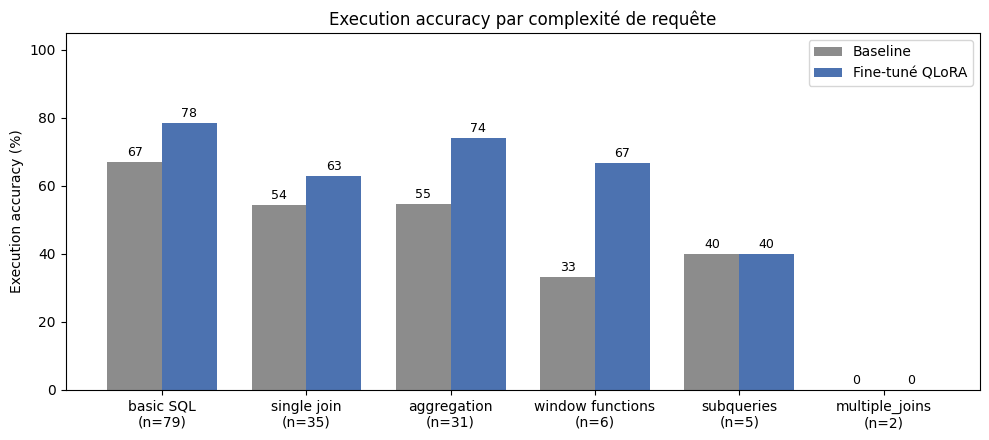

In [14]:
by_cx = pd.DataFrame({
    "n": base_res.groupby("sql_complexity").size(),
    "Baseline (%)": E.summarize_by(base_res)["execution_accuracy"],
    "Fine-tuné (%)": E.summarize_by(ft_res)["execution_accuracy"],
}).sort_values("n", ascending=False)
by_cx["Gain (points)"] = (by_cx["Fine-tuné (%)"] - by_cx["Baseline (%)"]).round(1)
display(by_cx)

labels = [f"{cx}\n(n={k})" for cx, k in zip(by_cx.index, by_cx["n"])]
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(by_cx)); w = 0.38
b1 = ax.bar(x - w/2, by_cx["Baseline (%)"], w, label="Baseline", color="#8C8C8C")
b2 = ax.bar(x + w/2, by_cx["Fine-tuné (%)"], w, label="Fine-tuné QLoRA", color="#4C72B0")
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=9); ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=9)
ax.set_xticks(x, labels); ax.set_ylim(0, 105); ax.set_ylabel("Execution accuracy (%)")
ax.set_title("Execution accuracy par complexité de requête"); ax.legend(); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_by_complexity.png", dpi=150)
plt.show()

⚠️ Les catégories de moins de 10 questions (window functions, subqueries, multiple joins) ne permettent pas de conclusion fiable.

### 8.3 Types d'erreurs

,Baseline,Fine-tuné
Correct,93,113
SQL valide mais faux,53,43
SQL invalide,12,2


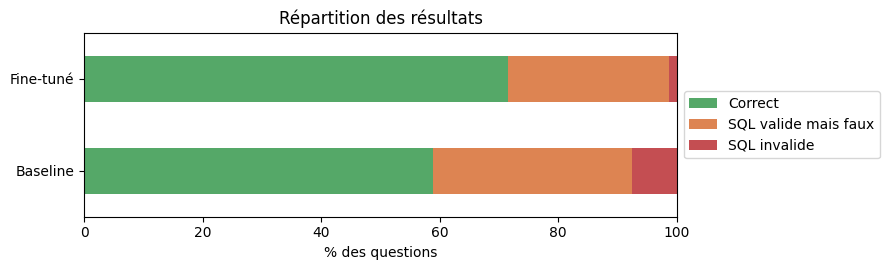

In [15]:
def outcome(res):
    return pd.Series({
        "Correct": int(res["execution_match"].sum()),
        "SQL valide mais faux": int((res["executable"] & ~res["execution_match"]).sum()),
        "SQL invalide": int((~res["executable"]).sum()),
    })

outcomes = pd.DataFrame({"Baseline": outcome(base_res), "Fine-tuné": outcome(ft_res)})
display(outcomes)

ax = (100 * outcomes / n).T.plot.barh(stacked=True, figsize=(9, 2.8), color=["#55A868", "#DD8452", "#C44E52"])
ax.set_xlabel("% des questions"); ax.set_xlim(0, 100); ax.set_title("Répartition des résultats")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 Exemples

In [16]:
merged = base_res[["question", "gold_sql", "pred_sql", "execution_match"]].rename(
    columns={"pred_sql": "baseline_sql", "execution_match": "baseline_ok"})
merged["finetuned_sql"] = ft_res["pred_sql"]
merged["finetuned_ok"] = ft_res["execution_match"]

def show(df, title, k=3):
    print(f"===== {title} ({len(df)}) =====\n")
    for _, r in df.head(k).iterrows():
        print(f"QUESTION  : {r['question']}\nRÉFÉRENCE : {r['gold_sql']}")
        print(f"BASELINE  : {r['baseline_sql']}\nFINE-TUNÉ : {r['finetuned_sql']}\n" + "-" * 80)

show(merged[~merged["baseline_ok"] & merged["finetuned_ok"]], "Corrigées par le fine-tuning")
show(merged[merged["baseline_ok"] & ~merged["finetuned_ok"]], "Cassées par le fine-tuning")

===== Corrigées par le fine-tuning (24) =====

QUESTION  : How many clients have taken out socially responsible loans in each country?
RÉFÉRENCE : SELECT country, COUNT(DISTINCT client_id) as num_clients FROM socially_responsible_loans GROUP BY country;
BASELINE  : SELECT COUNT(*) AS num_clients, country FROM socially_responsible_loans GROUP BY country;
FINE-TUNÉ : SELECT country, COUNT(*) FROM socially_responsible_loans GROUP BY country;
--------------------------------------------------------------------------------
QUESTION  : What is the average financial wellbeing score in Q2 2022 for customers with a Shariah-compliant finance account?
RÉFÉRENCE : SELECT AVG(financial_wellbeing_score) FROM shariah_compliant_customers WHERE shariah_compliant_account = true AND wellbeing_assessment_date BETWEEN '2022-04-01' AND '2022-06-30';
BASELINE  : SELECT AVG(financial_wellbeing_score) 
FROM shariah_compliant_customers 
WHERE wellbeing_assessment_date BETWEEN '2022-04-01' AND '2022-06-30';
FINE

In [17]:
comparison.to_csv(f"{RESULTS_DIR}/comparison.csv")
by_cx.to_csv(f"{RESULTS_DIR}/by_complexity.csv")
merged.to_csv(f"{RESULTS_DIR}/predictions_side_by_side.csv", index=False)
E.save_json({"n_test": n, "baseline": base_sum, "finetuned": ft_sum,
             "mcnemar": {"fixed": c, "broken": b, "p_value": round(p_value, 5)},
             "trainable_params": trainable, "adapter_mb": adapter_mb, "train_minutes": train_minutes},
            f"{RESULTS_DIR}/final_metrics.json")

gain = ft_sum["execution_accuracy"] - base_sum["execution_accuracy"]
print(f"""SYNTHÈSE
Execution accuracy : {base_sum['execution_accuracy']} % → {ft_sum['execution_accuracy']} % ({gain:+.1f} points) sur {n} questions
SQL valide         : {base_sum['valid_sql_rate']} % → {ft_sum['valid_sql_rate']} %
McNemar            : {c} questions corrigées, {b} cassées, p = {p_value:.4f}
Coût               : {trainable / 1e6:.1f} M paramètres entraînés, {train_minutes} min sur T4, adaptateur de {adapter_mb} Mo""")

SYNTHÈSE
Execution accuracy : 58.86 % → 71.52 % (+12.7 points) sur 158 questions
SQL valide         : 92.41 % → 98.73 %
McNemar            : 24 questions corrigées, 4 cassées, p = 0.0002
Coût               : 18.5 M paramètres entraînés, 18.5 min sur T4, adaptateur de 85.3 Mo


## 9. Limitations

- **Données synthétiques** : les schémas Gretel sont petits (1 à 3 tables) et propres, loin des bases bancaires réelles (centaines de tables, noms de colonnes cryptiques, valeurs sales).
- **Jeu de test réduit** : 158 questions, soit une incertitude d'environ ±7 points (voir les intervalles de confiance). Les catégories `window functions`, `subqueries` et `multiple_joins` comptent moins de 10 questions.
- **Même distribution** : train et test viennent du même générateur. Une partie du gain peut refléter l'adaptation au style de Gretel plutôt qu'une meilleure compréhension générale du SQL.
- **Métrique** : l'execution accuracy compare des ensembles de lignes. Une réponse raisonnable avec une colonne en plus est comptée fausse, et une requête fausse peut tomber juste par hasard sur une petite base.
- **Une seule configuration** : un seul rang (r = 16), une seule graine aléatoire, pas d'étude d'ablation.
- **Précision** : l'adaptateur est entraîné sur le modèle en 4 bits puis appliqué au modèle en float16 pour l'évaluation (procédure courante).
- **SQLite et questions en anglais uniquement.**

**Perspectives :** évaluation sur la base bancaire réelle `financial` du benchmark BIRD, comparaison de plusieurs rangs LoRA (4, 8, 16, 32), comparaison avec un grand modèle propriétaire, questions en français, et intégration dans un agent conversationnel.

## 10. Conclusion

Ce projet montre qu'un petit modèle open source (Qwen2.5-Coder, 1,5 milliard de paramètres), fine-tuné avec QLoRA sur un seul GPU gratuit, améliore nettement la génération de requêtes SQL sur des bases financières : l'execution accuracy passe de **58,9 %** à **71,5 %** (**+12,7 points**) sur 158 questions de test. Ce gain est **statistiquement significatif** (test de McNemar, p = 0,0002) : le fine-tuning corrige 24 questions et n'en casse que 4. Le modèle ne produit presque plus de SQL invalide (de 12 à 2 requêtes), et progresse surtout sur les agrégations (+19 points). Ce résultat a été obtenu en n'entraînant qu'environ **1,2 % des paramètres**, en **18,5 minutes** sur un GPU T4 gratuit, avec un adaptateur de **85 Mo**, et le modèle reste déployable en interne, sans envoyer de données à une API externe. Le principal point faible reste la logique des requêtes : 43 requêtes s'exécutent mais renvoient un mauvais résultat. Ces résultats restent à confirmer sur des bases bancaires réelles, plus complexes que les données synthétiques utilisées ici.

## 11. Références

1. Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models*, ICLR 2022. https://arxiv.org/abs/2106.09685
2. Dettmers et al., *QLoRA: Efficient Finetuning of Quantized LLMs*, NeurIPS 2023. https://arxiv.org/abs/2305.14314
3. Li et al., *Can LLM Already Serve as a Database Interface? (BIRD)*, NeurIPS 2023. https://arxiv.org/abs/2305.03111
4. Kumar et al., *BookSQL: A Large Scale Text-to-SQL Dataset for Accounting Domain*, NAACL 2024. https://aclanthology.org/2024.naacl-long.28
5. Zhang et al., *FinSQL: Model-Agnostic LLMs-based Text-to-SQL Framework for Financial Analysis*, SIGMOD 2024. https://arxiv.org/abs/2401.10506
6. Gretel AI, *synthetic_text_to_sql* (dataset, Apache 2.0). https://huggingface.co/datasets/gretelai/synthetic_text_to_sql
7. Qwen Team, *Qwen2.5-Coder-1.5B-Instruct* (modèle, Apache 2.0). https://huggingface.co/Qwen/Qwen2.5-Coder-1.5B-Instruct